<h1 style= 'text-align: center;'> ✈ Aviation Risk Analysis Project</h1>

---


## 📘 Project Overview

In this project, I will use data cleaning, imputation, analysis, and visualization to generate insights for a business stakeholder.
The company is expanding into new industries to diversify its portfolio. Specifically, they are interested in purchasing and operating airplanes for commercial and private enterprises, but do not currently know anything about the potential risks of aircraft.

I have been tasked with determining which aircraft have the lowest risk to help guide this new business venture. The results will inform actionable insights for the head of the new aviation division regarding aircraft purchasing decisions.

To determine which aircraft pose the least risk, we applied a process of elimination by filtering out aircraft categories with high accident rates or unreliable data. This ensured that our recommendations are based only on reliable and low-risk options.

## 💼 Work Completed

1. **Data Cleaning**
   - Loaded and filtered relevant columns from the dataset (AviationData.csv).
   - Handled missing values and dropped incomplete rows.
   - Created new features such as Total.Injured and extracted Year from Event.Date.
---

2. **Accident Rate Analysis by Aircraft Category**
   - Grouped the data by Aircraft.Category and calculated the total number of accidents.
   - Computed accident rates to normalize accident counts across categories.
   - Identified categories with the lowest and highest accident rates.
---

3. **Severity-Based Analysis**
   - Evaluated accident severity within each aircraft category.
   - Calculated accident rates for each severity level to assess risk exposure.
---


4. **Aircraft Damage Impact**
   - Compared the frequency and rate of accidents based on the extent of aircraft damage.
   - Highlighted how different aircraft types and damage categories contribute to overall risk.
---


5. **Final Aircraft Selection Based on Combined Safety Criteria**
   - Summary. 


## 1. 📊  Data cleaning

In this section, I performed initial data cleaning steps to prepare the dataset for analysis

In [294]:
# Imported essential libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read the CSV file AviationData.csv using the correct encoding and selected only relevant columns for the analysis
data = pd.read_csv('AviationData.csv', encoding='ISO-8859-1', low_memory = False, usecols = ['Investigation.Type', 'Event.Date', 'Injury.Severity' ,'Aircraft.damage', 'Aircraft.Category', 'Make', 'Number.of.Engines', 'Engine.Type', 'Purpose.of.flight', 'Total.Fatal.Injuries', 'Total.Serious.Injuries', 'Total.Minor.Injuries', 'Total.Uninjured'], parse_dates= ['Event.Date'])
pd.set_option('display.max_columns', 14)

# Removed rows where any of the following important fields were missing (NaN)
data = data.dropna(subset= ['Injury.Severity', 'Aircraft.damage', 'Aircraft.Category', 'Make', 'Number.of.Engines', 'Engine.Type', 'Purpose.of.flight', 'Total.Fatal.Injuries', 'Total.Serious.Injuries', 'Total.Minor.Injuries', 'Total.Uninjured' ]) 

#Replaced all types of 'Fatal' by 'Fatal'
data['Injury.Severity'] = data['Injury.Severity'].apply(lambda x: 'Fatal' if 'Fatal' in x and x != 'Non-FAtal' else 'Non-Fatal')

data = data[data['Aircraft.Category'] != 'Unknown']

# Created a new column (Total.Injured) in computed the total number of injuries (Total.Injured) by summing up fatal, serious, and minor injuries
data['Total.Injured'] = data['Total.Fatal.Injuries'] + data['Total.Serious.Injuries'] + data['Total.Minor.Injuries']                                        

# Converted the Event.Date column to datetime format and extracted only the year to create a new Year column
data['Year'] = data['Event.Date'].dt.year 
data.drop(columns=['Event.Date'], inplace= True) # Removed the original Event.Date column after extracting the year.
data.to_csv('Aviation_data_cleaned.csv', index = False)
data.head()

,Investigation.Type,Injury.Severity,Aircraft.damage,Aircraft.Category,Make,Number.of.Engines,Engine.Type,Purpose.of.flight,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Total.Injured,Year
7,Accident,Fatal,Substantial,Airplane,Cessna,1.0,Reciprocating,Personal,0.0,0.0,0.0,2.0,0.0,1982
8,Accident,Fatal,Substantial,Airplane,Cessna,2.0,Reciprocating,Business,0.0,0.0,0.0,2.0,0.0,1982
12,Accident,Fatal,Destroyed,Airplane,Bellanca,1.0,Reciprocating,Personal,0.0,0.0,1.0,0.0,1.0,1982
13,Accident,Fatal,Destroyed,Airplane,Cessna,1.0,Reciprocating,Personal,1.0,0.0,0.0,0.0,1.0,1982
14,Accident,Fatal,Destroyed,Airplane,Navion,1.0,Reciprocating,Personal,1.0,0.0,0.0,0.0,1.0,1982


## 2. Accident Rate Analysis by Aircraft Category

In this section, I analyzed the number and rate of accidents across different types of aircraft categories. To support informed decision-making, I applied an elimination strategy by removing aircraft categories whose accident rate exceeds 5%. This threshold-based filtering helps focus the analysis on aircraft types statistically associated with lower accident risks.

In [295]:
# Selected only rows that are 'Accident' in the Investigation.Type column
Accident = data['Investigation.Type'] =='Accident'
Total_Accidents = Accident.sum()  # sum of Accident in this coulumn

This step helps identify which categories of aircraft are statistically involved in fewer accidents, forming the basis for risk comparison across aircraft types

In [296]:
data['Number of accident'] = data['Investigation.Type'] # Created a new column as the Investigate.Type in data
data = data[data['Number of accident'] == 'Accident']  #This column countains only 'Accident' in the column Investigate.Type

grouped = data.groupby(['Aircraft.Category']).agg({'Number of accident' : 'count'})  # Grouped the dataset by Aircraft.Category and calculated the total number of accidents for each category

grouped['Accident.Rate']= grouped['Number of accident']/20382*100  # Calculated the accident rate as a percentage of the total accidents for each category, using the formula : Accident Rate = (Number of Accidents in Category / Total Accidents) × 100

grouped.sort_values(['Accident.Rate'] , ascending= True)

,Number of accident,Accident.Rate
Aircraft.Category,,
Blimp,1,0.004906
WSFT,1,0.004906
Ultralight,15,0.073594
Balloon,24,0.117751
Powered Parachute,80,0.392503
Glider,120,0.588755
Gyrocraft,134,0.657443
Weight-Shift,138,0.677068
Helicopter,1975,9.689922


In [297]:
threshold = 5
low_risk_aircraft = grouped[grouped['Accident.Rate'] <= threshold]
print('Aircraft categories with accident rate less than or equal to', threshold, '%' ' : \n' )
display(low_risk_aircraft.sort_values(['Accident.Rate'] , ascending= True))

Aircraft categories with accident rate less than or equal to 5 % : 



,Number of accident,Accident.Rate
Aircraft.Category,,
Blimp,1,0.004906
WSFT,1,0.004906
Ultralight,15,0.073594
Balloon,24,0.117751
Powered Parachute,80,0.392503
Glider,120,0.588755
Gyrocraft,134,0.657443
Weight-Shift,138,0.677068


### Visualization
This bar chart illustrates the accident rate by aircraft category. It visually highlights which Aircraft categories with accident rate less than or equal to 5 %.

C:\Users\RIchKard\AppData\Local\Temp\ipykernel_9912\2010543008.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(low_risk_aircraft, x = 'Aircraft.Category', y = 'Number of accident', palette = 'colorblind')


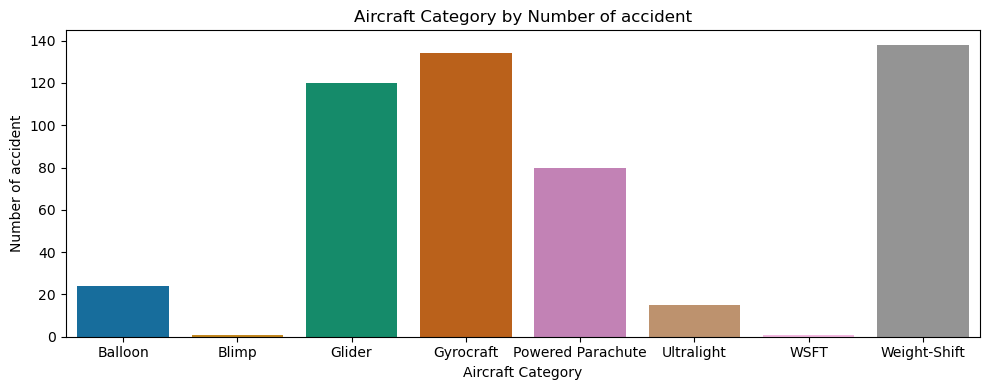

In [293]:
plt.figure(figsize=(10, 4))
sns.barplot(low_risk_aircraft, x = 'Aircraft.Category', y = 'Number of accident', palette = 'colorblind')
plt.title('Aircraft Category by Number of accident')
plt.xlabel("Aircraft Category")
plt.ylabel("Number of accident")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. Severity-Based Analysis

In this analysis, I examined the severity of injuries (Fatal vs. Non-Fatal) across aircraft categories previously identified as low-risk.

To maintain consistency with the elimination strategy applied earlier, I excluded aircraft types that had already been filtered out due to high accident rates—such as *Airplanes* and *Helicopters*— as well as accidents categorized as Fatal. 

The aim is to assess the injury severity profile *only among safer aircraft*, helping identify if even low-risk aircraft types are disproportionately prone to severe outcomes.

The accident rate is calculated as a percentage of total accidents in the dataset, which allows for meaningful comparison of severity exposure across retained aircraft categories.

In [284]:
# Grouped by Aircraft Category and Injury Severity & calculated the number of accidents for each severity level
group = data.groupby(['Aircraft.Category', 'Injury.Severity' ]).agg({'Number of accident' : 'count' })  
group['Accident.Rate']= group['Number of accident']/20382*100 

display(group.sort_values(['Accident.Rate'] , ascending= True))

,,Number of accident,Accident.Rate
Aircraft.Category,Injury.Severity,,
Gyrocraft,Non-Fatal,1,0.004906
WSFT,Non-Fatal,1,0.004906
Powered Parachute,Non-Fatal,2,0.009813


In [285]:
data = data[data['Aircraft.Category'] != 'Airplane']
data = data[data['Aircraft.Category'] != 'Helicopter']
data = data[data['Injury.Severity'] != 'Fatal']

group = data.groupby(['Aircraft.Category', 'Injury.Severity' ]).agg({'Number of accident' : 'count' })  
group['Accident.Rate']= group['Number of accident']/20382*100 

print('Severity analysis limited to safer aircraft categories (Non-Fatal only) : \n')
display(group.sort_values(['Accident.Rate'] , ascending= True))

Severity analysis limited to safer aircraft categories (Non-Fatal only) : 



,,Number of accident,Accident.Rate
Aircraft.Category,Injury.Severity,,
Gyrocraft,Non-Fatal,1,0.004906
WSFT,Non-Fatal,1,0.004906
Powered Parachute,Non-Fatal,2,0.009813


### Visualization
This chart provides a visual representation of the injury severity distribution among aircraft categories that were retained after the risk-based elimination process.

As seen, all displayed accidents are non-fatal, confirming that only low-risk aircraft types are included. This visualization supports the analysis by making it easy to compare which retained aircraft categories have the most frequent (though non-severe) incidents.

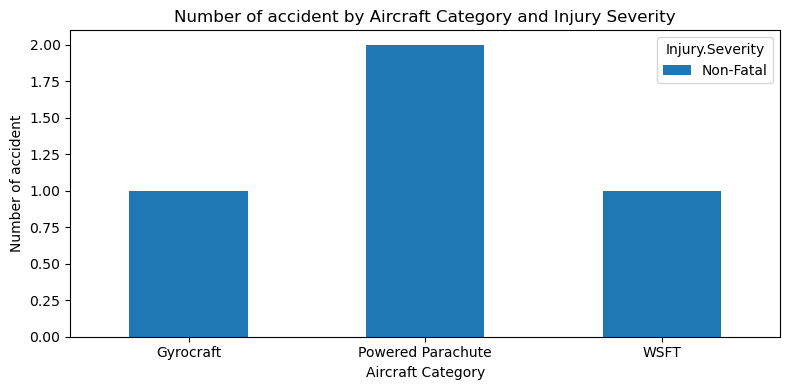

In [286]:
# Grouped the data by both Aircraft.Category and Injury.Severity to understand how accident severity differs by aircraft type
# Counted accident occurrences for each severity level using .size() and reshaped the result with .unstack() to prepare it for visualization.
# Created a stacked bar chart to visually represent the number of accidents per aircraft category, broken down by severity level.
group = data.groupby(['Aircraft.Category', 'Injury.Severity']).size().unstack(fill_value=0)

group.plot(kind='bar', stacked=True, figsize=(8, 4))
plt.title('Number of accident by Aircraft Category and Injury Severity')
plt.xlabel("Aircraft Category")
plt.ylabel('Number of accident')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 4. Aircraft Damage Impact

In this section, I analyzed how the extent of aircraft damage influences the number of accidents across retained aircraft categories.  
By grouping accidents based on both aircraft category and the level of damage (e.g., Substantial, Destroyed), this analysis provides insight into the *physical consequences* of incidents among aircraft already identified as low-risk.

While the frequency of accidents may be low, certain aircraft may still be more prone to serious structural damage, which is critical for *operational safety* and *maintenance cost considerations*.

This step ensures that aircraft selection decisions are informed not only by how often accidents occur, but also by *how damaging those accidents tend to be*.


In [287]:
# Grouped the dataset by both Aircraft.Category and Aircraft.damage & counted the number of accidents for each damage level
data['Number of accident'] = data['Investigation.Type'] # Created a new column as the Investigate.Type in data
data = data[data['Number of accident'] == 'Accident'] 

group = data.groupby(['Aircraft.Category', 'Aircraft.damage']).agg({'Number of accident' : 'count'})

group['Accident.Rate']= group['Number of accident']/20382*100

group.sort_values(['Aircraft.Category'], ascending= True)

Number of accident  Accident.Rate
Aircraft.Category Aircraft.damage                                   
Gyrocraft         Substantial                       1       0.004906
Powered Parachute Destroyed                         1       0.004906
                  Substantial                       1       0.004906
WSFT              Substantial                       1       0.004906

### Visualization
This chart shows the distribution of damage levels among accidents for each retained aircraft category.  
Even among aircraft with low accident rates, the *severity of physical damage* can differ significantly.  
This visualization helps identify which aircraft types tend to suffer more serious structural damage versus more moderate damage, which is a key consideration for safety and operational planning.

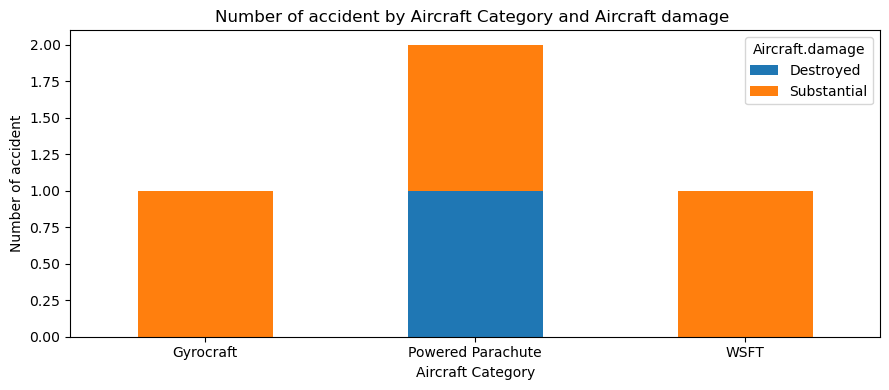

In [288]:
group = data.groupby(['Aircraft.Category', 'Aircraft.damage']).size().unstack(fill_value=0)

group.plot(kind='bar', stacked=True, figsize=(9, 4))
plt.title('Number of accident by Aircraft Category and Aircraft damage ')
plt.xlabel("Aircraft Category")
plt.ylabel('Number of accident')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 5. Final Aircraft Selection Based on Combined Safety Criteria

This final step consolidates the analysis by comparing all relevant factors across the retained aircraft categories.  
The goal is to identify the safest and most operationally viable aircraft based on:

- Injury severity
- Damage level sustained
- Number and type of engines
- Purpose of flight
- Manufacturer (Make)
- Year of the aircraft

In [289]:
# Grouped the data by both Aircraft.Category and Number.of.Engines & Aggregated injury data, including total injured, uninjured, fatal injuries and Number of accident for each group.
grouped = data.groupby(['Aircraft.Category', 'Injury.Severity', 'Aircraft.damage' ,"Number.of.Engines", 'Engine.Type', 'Purpose.of.flight','Make', 'Year']).agg({'Number of accident' : 'count'})

grouped.sort_values(['Aircraft.Category'], ascending= True)

Number of accident
Aircraft.Category Injury.Severity Aircraft.damage Number.of.Engines Engine.Type   Purpose.of.flight Make                 Year                    
Gyrocraft         Non-Fatal       Substantial     1.0               Reciprocating Personal          AUTOGYRO             2022                   1
Powered Parachute Non-Fatal       Destroyed       1.0               Reciprocating Personal          SIX CHUTER           2022                   1
                                  Substantial     1.0               Reciprocating Personal          DESTINY              2022                   1
WSFT              Non-Fatal       Substantial     1.0               Reciprocating Personal          AIR CREATION USA LLC 2022                   1

### Summary

All remaining aircraft—*Gyrocraft*, *Powered Parachute*, and *WSFT*—meet the following safety criteria:
- Involved only in *non-fatal* accidents
- All used *1 reciprocating engine*
- Accidents occurred during *personal use*
- All models were from the year *2022*

However, key differences emerge upon deeper inspection:

- *Damage Level*:
  - *Powered Parachute* experienced a *"Destroyed"* outcome, indicating a total loss. This level of damage implies significantly higher repair or replacement costs and increased risk.
  - In contrast, *Gyrocraft* and *WSFT* were both classified as *"Substantial"* damage — serious but typically repairable.

- *Purpose of Flight*:
  - All incidents occurred during *personal* flights. No accidents related to *business*, *instructional*, or *commercial* use were recorded in this subset.
  - This limits the generalizability of the findings for other flight purposes. Any future consideration of these aircraft for broader usage should be approached with additional caution and data.

Based on the full set of safety indicators:

- *Gyrocraft* is the most reliable choice. It combines a clean safety record (non-fatal, substantial damage only) with consistent configuration and modern manufacture.
- *WSFT* is a close second, presenting similar characteristics and performance in the filtered dataset.

While *Powered Parachute* meets basic safety criteria, its involvement in a "Destroyed" level incident makes it a *less favorable option* for immediate selection. It may still be considered in secondary scenarios, but with increased attention to cost implications and physical vulnerability.

##### If a final decision must be made, *Gyrocraft* and *WSFT* are the most appropriate and lowest-risk options.
